# Модель для прогнозирования оттока клиентов для сервиса доставки кофе


**Дата:** 10.08.2026  
**Выполнил:** Курмышкин Андрей

## План работы

1. Загрузка и первичный анализ данных.
2. Исследовательский анализ данных (EDA).
3. Предобработка и подготовка признаков.
4. Построение baseline-модели.
5. Создание и отбор новых признаков.
6. Подбор гиперпараметров и порога классификации.
7. Обучение и оценка финальной модели.
8. Итоговый отчёт по результатам проекта.
9. Сохранение модели и проверка загрузки артефакта.

## Этап 1. Подготовка среды и библиотек

### [Ссылка на гитхаб с `requirements.txt`.](https://github.com/andreiyopt/coffee_churn_model)

In [2]:
# скрываем только ожидаемые FutureWarning от sklearn
import warnings

warnings.filterwarnings(
    'ignore',
    category=FutureWarning,
    module='sklearn'
)

In [3]:
# импортируем нужные в проекте библиотеки

import pandas as pd                                     # датафреймы и работы с данными
import numpy as np                                      # работа с массивами 

import matplotlib.pyplot as plt                         # визуализация
import seaborn as sns                                   # тепловые карты

from sklearn.model_selection import train_test_split    # разделение на выборки
from sklearn.model_selection import cross_validate      # кросс-валидация
from sklearn.model_selection import  StratifiedKFold
from sklearn.model_selection import cross_val_predict 

from sklearn.compose import ColumnTransformer           # создание транмсформеров
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline                   # создание пайплайна
from sklearn.impute import SimpleImputer                # заполнение значений
from sklearn.preprocessing import OneHotEncoder         # скейлинг
from sklearn.preprocessing import StandardScaler        # скейлинг

                                                        # модели обучения
from sklearn.linear_model import LogisticRegression     # логистическая регрессия           
from sklearn.dummy import DummyClassifier               # дамми модель

from sklearn.metrics import accuracy_score              # метрики качества обучения
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss

from sklearn.feature_selection import SelectFromModel   # выбор лучших вариантов модели 
from sklearn.model_selection import GridSearchCV

import joblib                                           # сохранение модели

In [4]:
# фиксируем рандом_стейт
RANDOM_STATE = 42

In [5]:
# извлекаем датафрейм
# для удобства локальной работы датасет помещен в папку проекта, поэтому адрес начинается с '../', однако в 
# финальной версии путь будет изменен на '/'
try: 
    data = pd.read_csv('../datasets/coffee_churn_dataset.csv', sep=',', decimal='.')   
except:  
    data = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
    
df_churn = pd.DataFrame(data)

# проверяем загрузку
display(df_churn.head(5))
print('Dataframe succesfully loaded!')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Dataframe succesfully loaded!


## Этап 2. Первичный анализ данных

### 1. Краткое описание данных

In [6]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

На первый взгляд данные не содержат большого количества пропусков. Всего 17 числовых значений и 10 категориальных. 

In [7]:
display(df_churn.describe())

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [8]:
display(df_churn.describe(include='object'))

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_07561,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


- Даже до детального изучения заметно наличие выбросов.   
  
- Вцелевой переменной churn заметен дисбаланс
  
- В данных есть отрицательные значения, в местах где, по идее, их не должно быть

In [9]:
# проверяем отрицальные значения:
negative_counts = (df_churn.select_dtypes(include='number') < 0).sum()
negative_counts[negative_counts > 0].sort_values(ascending=False)

total_spent_last_week     171
order_frequency_week       83
review_rating_last_1        6
avg_order_value             2
median_order_value          2
total_spent_last_month      2
dtype: int64

Отрицательные значения невозможны в данных столбцах. Стоит заменить их на нан и заполнить медианой после разделения на выборки.

#### Краткое описание данных — вывод

Датасет содержит 10 450 наблюдений и 27 столбцов: 17 числовых и 10 категориальных. В данных присутствуют пропуски, выбросы и физически невозможные отрицательные значения, а в целевой переменной `churn` наблюдается выраженный дисбаланс классов.


### 2. Описание признаков



Необходимо определить, какие признаки могут быть полезны для модели, а от каких можно избавиться.

1. `user_id` необходимо исключить, поскольку это уникальный идентификатор, а не содержательный признак. Модель может запомнить отдельных пользователей, но не сможет использовать эту информацию для новых клиентов.

2. `days_since_last_order` следует исключить только в том случае, если целевая переменная `churn` была сформирована на его основе. Если оттоком считается отсутствие заказов в течение определённого количества дней, модель фактически получает информацию, по которой уже был определён целевой класс. Это создаёт утечку целевого признака и приводит к завышенной оценке качества модели.

3. Между `частотой заказов в месяц` и `частотой заказов в неделю` предположительно существует сильная корреляция. Чтобы избежать мультиколлинеарности, можно оставить только частоту заказов в месяц. После проверки на обучающей выборке стоит вернуться к этому вопросу.

4. Аналогичная ситуация возможна со `средней ценой заказа` и `медианной ценой заказа`. Необходимо проверить степень их корреляции на обучающей выборке.

5. Тот же принцип применим к признакам `всего потрачено за месяц` и `всего потрачено за неделю`.

6. `Доля заказов со скидкой` может быть связана с лояльностью пользователя, поэтому этот признак стоит оставить.

7. `Последний заказанный тип кофе`, `предпочитаемая обжарка`, `предпочтения в молоке` и `страна происхождения зерна`, скорее всего, не имеют сильной связи с лояльностью либо эта связь будет сложно интерпретироваться. Их полезность необходимо проверить после разделения данных на выборки.

8. `Отметка о том, пробовал ли пользователь новое меню` может быть связана с его лояльностью, поэтому признак стоит оставить.

9. `Размер последнего заказа` может содержать полезную информацию о поведении пользователя.

10. `Данные о подписке` могут быть важны для прогнозирования оттока.

11. `Количество открытий приложения` и `наличие включённых уведомлений` могут отражать активность пользователя и быть полезными для модели.

12. `Средняя оценка пользователя` может содержать больше информации, чем `последняя оценка`. При этом между этими признаками возможна мультиколлинеарность, поэтому к этому вопросу следует вернуться после анализа обучающей выборки.

13. `Тип телефона`, вероятно, связан с целевой переменной только косвенно. Например, можно выдвинуть гипотезу, что пользователи разных устройств отличаются по потребительскому поведению. Однако этот признак может оказаться лишним, поэтому пока его стоит оставить и проверить после разделения данных.

14. `Данные об изменении вкусовых предпочтений` (`1/0`) теоретически могут содержать полезную информацию о поведении пользователя.

15. `Геолокацию` также стоит оставить, поскольку регион пользователя может быть связан с вероятностью оттока.

In [10]:
# сравним распределение days_since_last_order между классами
df_churn.groupby('churn')['days_since_last_order'].agg(
    ['min', 'max', 'median', 'mean']
)

,min,max,median,mean
churn,,,,
0,0.0,40.0,3.0,4.407880
1,0.0,33.0,3.0,4.180385


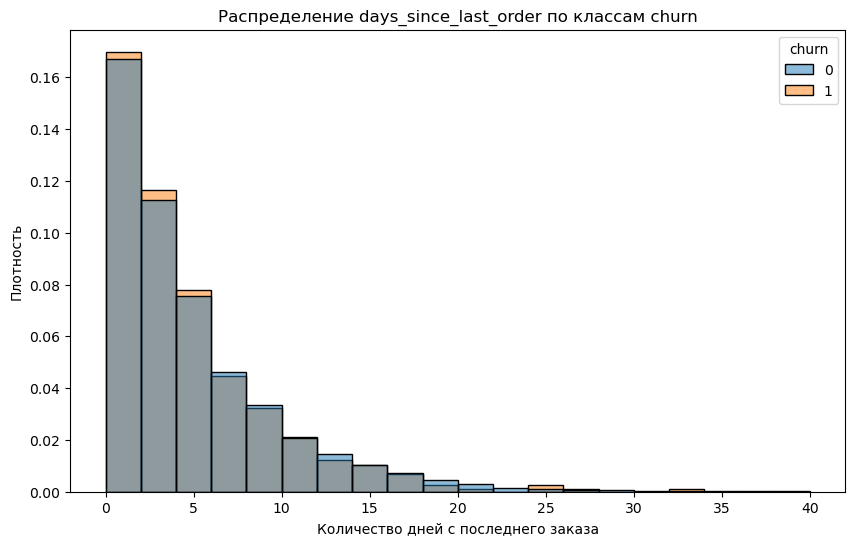

In [11]:
# сравним распределение days_since_last_order между классами
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_churn,
    x='days_since_last_order',
    hue='churn',
    bins=20,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.title('Распределение days_since_last_order по классам churn')
plt.xlabel('Количество дней с последнего заказа')
plt.ylabel('Плотность')
plt.show()

по одному этому признаку модель почти не сможет отличить ушедшего клиента от оставшегося. `days_since_last_order` почти одинаково распределён у ушедших и не ушедших клиентов.

#### Описание признаков — вывод

Уникальный идентификатор `user_id` необходимо удалить, поскольку он не содержит полезной информации для прогнозирования новых клиентов. Остальные признаки потенциально полезны, однако некоторые пары могут дублировать информацию, а `days_since_last_order` следует исключить только при подтверждении того, что `churn` был сформирован на его основе.


### 3. Категориальные признаки

In [12]:
display(df_churn.describe(include='object'))

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_07561,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


In [13]:
# проверим значения категорий
categorical_columns = df_churn.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f'\n{column}:')
    print(df_churn[column].unique())


user_id:
['user_00318' 'user_07234' 'user_04816' ... 'user_05390' 'user_00860'
 'user_07270']

last_coffee_type:
['blend' 'arabica' 'robusta' nan]

preferred_roast:
['light' 'medium' 'dark' nan]

milk_preference:
['almond' 'whole' 'oat' 'skim' 'soy' nan 'none']

coffee_bean_origin:
['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' nan 'ethiopia']

last_drink_size:
['large' 'medium' 'small' nan]

subscription_status:
['pro' 'none' 'premium' 'basic' nan]

seasons:
['summer' 'autumn' 'spring' 'winter' nan]

phone_type:
['android' 'ios' 'web' nan]

geo_location:
['geo_75' 'geo_95' 'geo_25' 'geo_2' 'geo_19' 'geo_68' 'geo_3' 'geo_45'
 'geo_15' nan 'geo_30' 'geo_93' 'geo_64' 'geo_40' 'geo_87' 'geo_17'
 'geo_11' 'geo_94' 'geo_1' 'geo_50' 'geo_67' 'geo_51' 'geo_97' 'geo_16'
 'geo_78' 'geo_100' 'geo_98' 'geo_43' 'geo_8' 'geo_48' 'geo_61' 'geo_74'
 'geo_35' 'geo_59' 'geo_46' 'geo_5' 'geo_23' 'geo_91' 'geo_42' 'geo_90'
 'geo_4' 'geo_96' 'geo_57' 'geo_71' 'geo_54' 'geo_65' 'geo_32' 'geo_14'
 'geo

Для категориальных признаков, включая geo_location, используется One-Hot Encoding. Влияние geo_location дополнительно будет проверено экспериментально.

In [14]:
# проверим также бинарные категории
binary_columns = [
    column for column in df_churn.columns
    if df_churn[column].dropna().nunique() == 2
]

for column in binary_columns:
    print(f'\n{column}:')
    print(df_churn[column].value_counts(dropna=False))


seasonal_menu_tried:
1.0    6634
0.0    2827
NaN     989
Name: seasonal_menu_tried, dtype: int64

notifications_enabled:
1.0    7465
0.0    2448
NaN     537
Name: notifications_enabled, dtype: int64

coffee_preference_change:
0.0    7946
1.0    1894
NaN     610
Name: coffee_preference_change, dtype: int64

churn:
0    9821
1     629
Name: churn, dtype: int64


Классы распредлены неравномерно - это стоит учитывать при состовлении модели.

####  Категориальные признаки — вывод

Категориальные признаки с небольшим количеством значений можно обработать с помощью One-Hot Encoding. Для `geo_location`, содержащего около 100 категорий, целесообразно рассмотреть Target Encoding, выполняемый строго внутри кросс-валидации, а бинарные признаки 0/1 дополнительного кодирования не требуют.


### 4. Обработка пропущеных значений

In [15]:
# проверим долю пропусков по каждому сстолбцу
(df_churn.isna().mean() * 100).sort_values(ascending=False)

seasonal_menu_tried         9.464115
days_since_last_order       9.043062
total_spent_last_week       9.033493
subscription_status         8.976077
app_opens_per_week          8.574163
review_rating_last_1        8.200957
median_order_value          7.952153
days_since_last_promo       6.995215
app_crashes_last_month      6.899522
review_rating_last_10       6.631579
coffee_bean_origin          6.526316
seasons                     6.497608
milk_preference             6.392344
coffee_preference_change    5.837321
order_frequency_month       5.741627
avg_order_value             5.578947
notifications_enabled       5.138756
last_drink_size             4.822967
discount_usage_rate         3.799043
order_frequency_week        3.712919
phone_type                  3.215311
total_spent_last_month      2.813397
last_coffee_type            2.468900
preferred_roast             1.110048
geo_location                1.052632
user_id                     0.000000
churn                       0.000000
d

* В `churn` нет пропусков.
  
* Непрерывные числовые признаки заполним `median`

* Бинарные 0/1 заполним через `most_frequent`, чтобы не получить искусственное значение 0.5

* Категориальные текстовые заполним `most_frequent`

In [16]:
# проверяем случайны ли пропуски или они имеют объяснение
df_churn[df_churn['days_since_last_order']==0]

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0
18,user_04393,0.0,5.236275,1.132846,2288.324775,801.929704,NaN,1000.598857,0.296605,arabica,...,0.0,4.415193,3.125482,0.0,winter,15.0,android,0.0,geo_2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10423,user_02747,0.0,3.109886,0.778299,1425.781082,500.314428,1655.038396,320.956247,0.502604,robusta,...,0.0,4.679483,5.461553,1.0,winter,1.0,android,0.0,geo_3,0
10425,user_07849,0.0,5.715180,1.322105,NaN,262.177589,1607.098459,394.697651,0.253532,arabica,...,1.0,2.932678,4.654892,1.0,spring,2.0,android,1.0,geo_36,0
10426,user_02558,0.0,3.623658,0.868063,1505.014884,588.101217,2338.612811,656.103566,0.402130,arabica,...,NaN,3.531941,5.070048,1.0,spring,NaN,ios,0.0,geo_15,0
10437,user_06949,0.0,8.249873,1.919361,1488.591551,520.805292,3537.475567,946.806456,0.226926,arabica,...,1.0,4.452741,3.512895,0.0,spring,9.0,ios,0.0,geo_52,0


In [17]:
df_churn[df_churn['total_spent_last_week'].isna()]   

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
17,user_02085,3.0,3.503378,0.936460,1001.051602,405.030466,1584.914584,NaN,0.435147,arabica,...,1.0,5.683203,5.187074,0.0,winter,NaN,ios,0.0,geo_3,0
21,user_03457,5.0,4.289869,NaN,2678.323579,1459.123886,6913.253220,NaN,0.168081,robusta,...,1.0,2.502726,3.759893,1.0,winter,46.0,ios,NaN,geo_94,0
43,user_07539,2.0,1.379313,0.289451,1235.152935,NaN,947.938062,NaN,0.438557,robusta,...,1.0,3.006368,NaN,1.0,winter,33.0,android,0.0,geo_100,0
57,user_04771,2.0,5.445011,1.373850,765.754316,299.811228,1885.775446,NaN,0.465748,robusta,...,1.0,4.964828,3.794571,0.0,autumn,32.0,ios,0.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10364,user_08571,NaN,2.850030,0.819650,386.270390,264.542002,814.544327,NaN,0.217156,arabica,...,1.0,3.758997,4.575189,1.0,autumn,3.0,android,0.0,geo_1,0
10374,user_06439,3.0,5.285265,1.273538,359.379477,257.865432,1252.671281,NaN,0.261663,blend,...,1.0,4.264202,4.017560,2.0,winter,22.0,NaN,0.0,geo_94,0
10385,user_09692,2.0,2.210407,0.471831,NaN,88.580720,167.262313,NaN,0.043340,robusta,...,1.0,4.282491,5.184235,0.0,winter,3.0,ios,0.0,geo_1,0
10433,user_06420,NaN,1.264390,0.593075,1062.297173,479.943650,536.683438,NaN,0.336729,blend,...,1.0,4.626942,3.307180,0.0,winter,27.0,ios,0.0,geo_52,0


Скорее всего, пропуски случайны, поэтому **после** разделения на выборки заполним их медианой, рассчитанной **только** на обучающей выборке.

#### пояснение

Можно было бы предположить, что НаН в "Тотал_спенд_ласт_вик" - это нулевые значения, но можно увидеть, что последний заказ сделан меньше недели назад, а значит значение 0 в тратах на неделю не может быть верным. Категориальные значения могут иметь NuN как аналог 0, но выше мы проверили все категории, и там четко указан "none" для, например, подписки, то есть нулевая категория есть, и нан значения скорее всего случайные пропуски

#### Обработка пропущенных значений — вывод

В отдельных столбцах доля пропусков не превышает примерно 10%, однако хотя бы один пропуск присутствует в 78,19% строк, поэтому удаление таких наблюдений приведёт к большой потере данных. Числовые признаки будут заполнены медианой, а бинарные и категориальные — наиболее частым значением, рассчитанным только по обучающей выборке внутри пайплайна.


### 5. Дубликаты

In [18]:
df_churn.duplicated().sum()

0

Явные дубликаты отсутсвуют. Неявные, судя по проверенным названиям категорий, тоже.

### 6. Возможные стратегии генерации новых признаков



На основе имеющихся данных можно создать несколько дополнительных признаков:

1. **Средний расход на один заказ**

   Отношение общей суммы расходов к количеству заказов:

   - `total_spent_last_month / order_frequency_month`
   - `total_spent_last_week / order_frequency_week`

   Такой признак может точнее отражать ценность клиента, чем расходы и количество заказов по отдельности.

2. **Изменение частоты заказов**

   Можно сравнить текущую недельную частоту заказов со средней недельной частотой, рассчитанной на основе месячных данных:

   - `order_frequency_week - order_frequency_month / 4`

   Отрицательное значение может указывать на снижение активности пользователя.

3. **Изменение расходов**

   Аналогично можно сравнить расходы за последнюю неделю со средними недельными расходами за месяц:

   - `total_spent_last_week - total_spent_last_month / 4`

   Снижение расходов может быть признаком возможного оттока.

4. **Отклонение последней оценки от средней**

   - `review_rating_last_1 - review_rating_last_10`

   Этот признак позволит определить, стало ли последнее впечатление пользователя лучше или хуже его обычной оценки.

5. **Интенсивность использования скидок**

   Можно объединить `discount_usage_rate` с частотой заказов или общей суммой расходов. Это поможет отделить активных постоянных клиентов от пользователей, совершающих покупки преимущественно из-за скидок.

6. **Активность пользователя**

   Можно создать общий показатель активности на основе:

   - `app_opens_per_week`;
   - `order_frequency_week`;
   - `notifications_enabled`;
   - `seasonal_menu_tried`.

7. **Стабильность приложения**

   Отношение количества сбоев приложения к количеству его открытий:

   - `app_crashes_last_month / (app_opens_per_week * 4)`

   Высокая доля сбоев может негативно влиять на пользовательский опыт и вероятность дальнейшего использования сервиса.

8. **Давность взаимодействия с сервисом**

   Можно объединить:

   - `days_since_last_order`;
   - `days_since_last_promo`.

   Эти признаки могут отражать снижение активности и интереса пользователя.

9. **Взаимодействие подписки и активности**

   Можно проверить сочетания `subscription_status` с частотой заказов, расходами и количеством открытий приложения. Например, низкая активность пользователя с платной подпиской может быть важным сигналом возможного оттока.

При создании отношений необходимо отдельно обработать случаи, когда знаменатель равен нулю. Окончательная полезность новых признаков будет оцениваться по результатам кросс-валидации.

#### Генерация новых признаков — вывод

На основе исходных данных можно создать признаки, отражающие изменение частоты заказов и расходов, средний расход на заказ, отклонение последней оценки от средней, интенсивность использования скидок и частоту сбоев приложения. Полезность новых признаков необходимо проверять по результатам кросс-валидации, не добавляя их все одновременно без проверки.


### 7. Выбросы

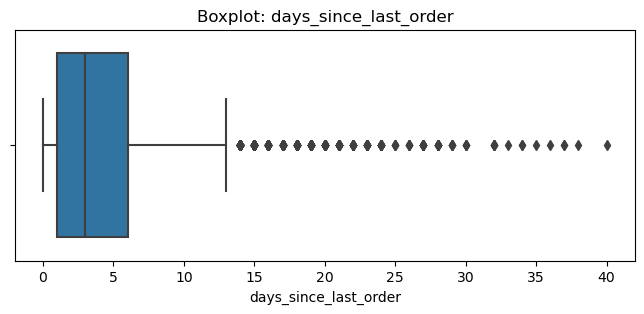

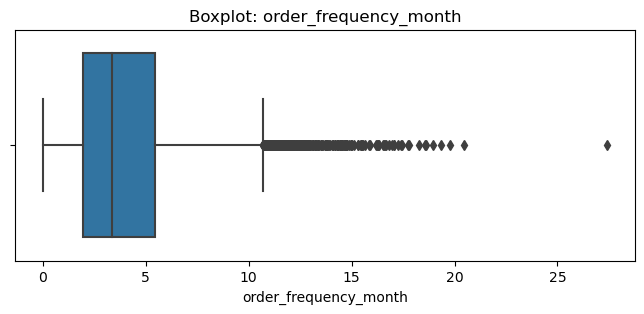

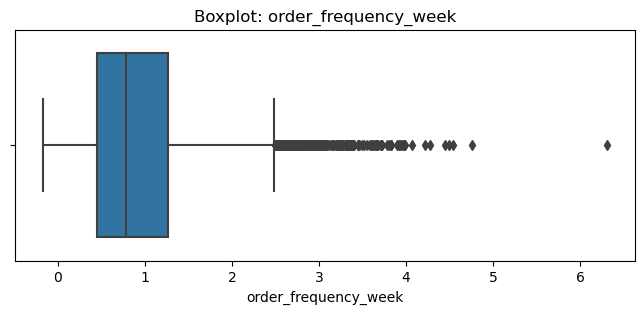

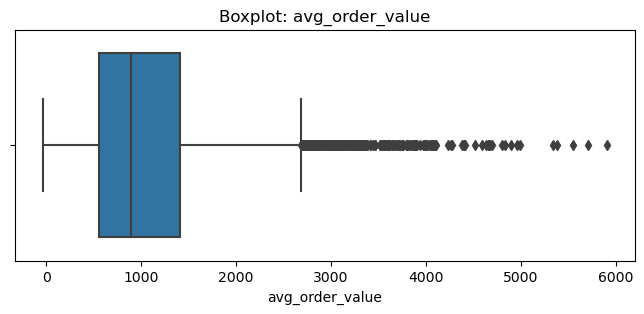

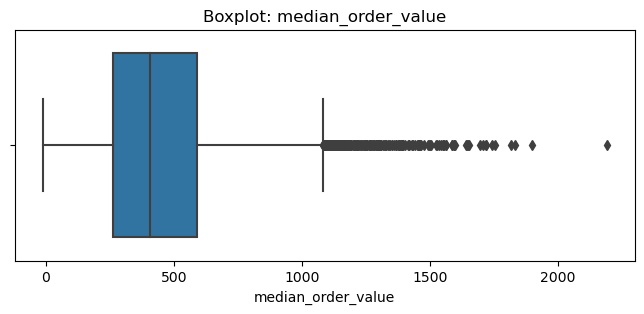

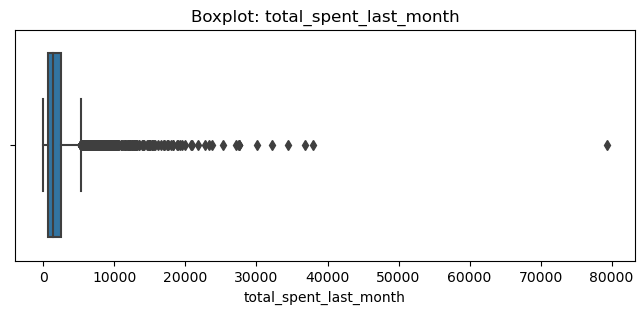

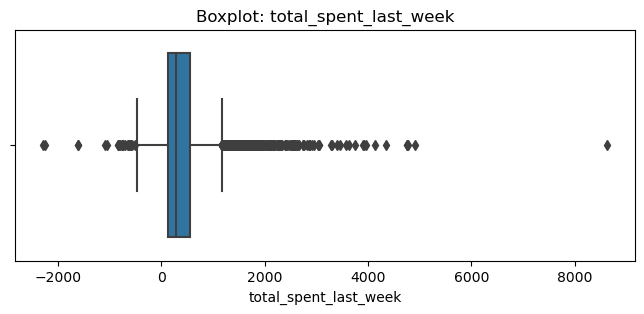

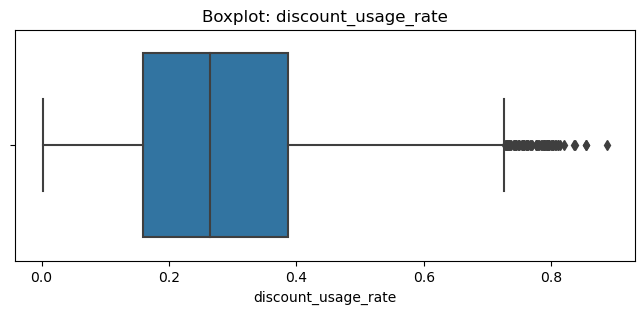

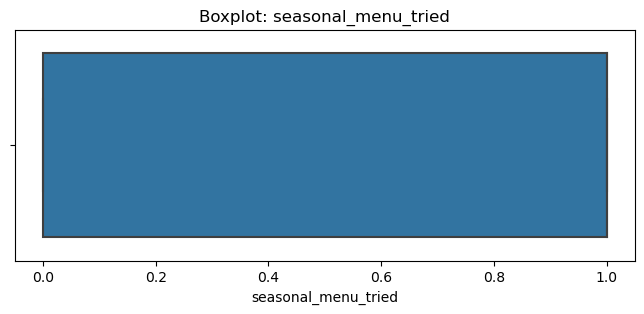

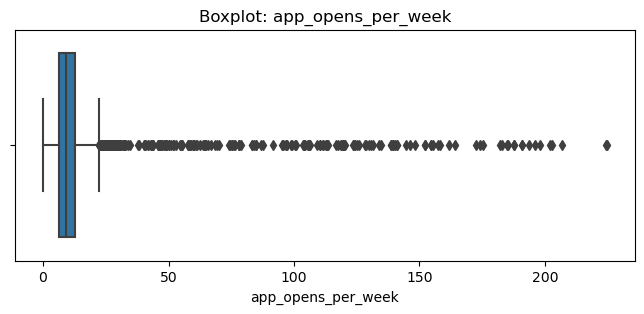

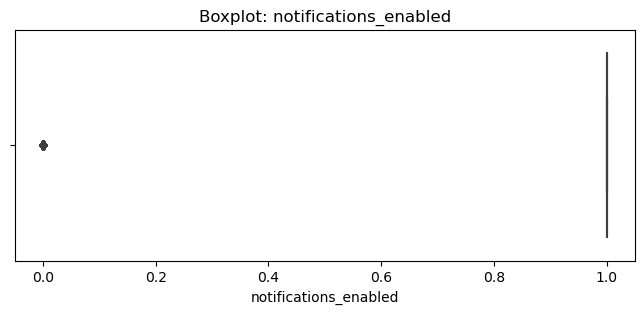

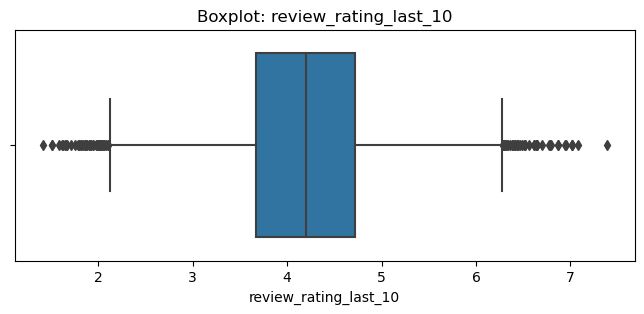

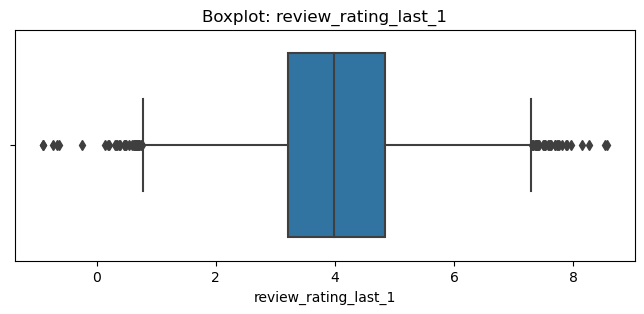

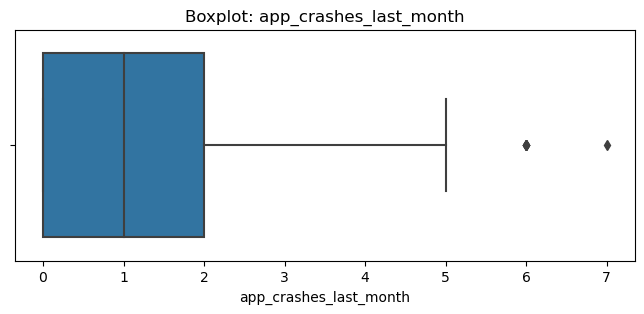

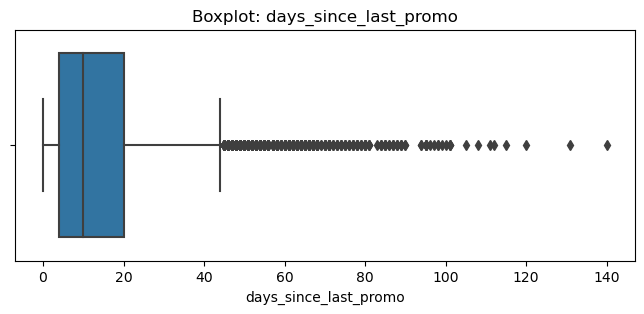

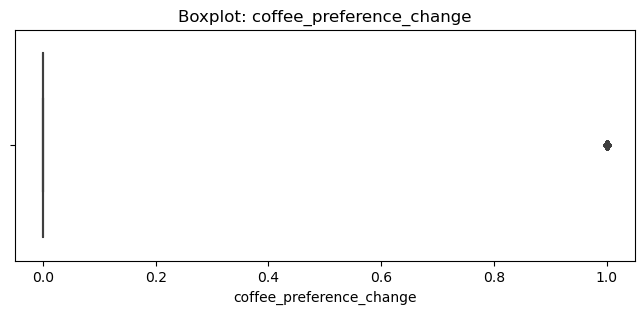

In [19]:
# отдельно визуализируем выбросы для каждого числового признака
numeric_columns = df_churn.select_dtypes(include='number').columns.drop('churn')

for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_churn[column])

    plt.title(f'Boxplot: {column}')
    plt.xlabel(column)

    plt.show()

Многочисленные выделяющиеся выбросы есть в `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`. Причем во всех столбцах кроме `total_spent_last_week` - это могут быть реальные значения. Даже 80к трат за месяц в `total_spent_last_month` - может быть реальной суммой (хотя скорее всего, всё-таки, выброс). Однако отрицатленых значений в тратах за неделю быть никак не может, поэтмоу после разделения на выборки нужно будет обработать выбросы.
  

Хорошей идеей будет заменить столбец `total_spent_last_month` на `log1p` и затем стандартизировать данные. Значения слишком высокие, а разница между 30к и 40к не такая существенная как между 1к и 10к. (то есть пользователи, которые тратят по 30-40к в месяц скорее всего примерно одного дохода, а доход тех, кто тратят 10к и 1к будет заметно отличаться)



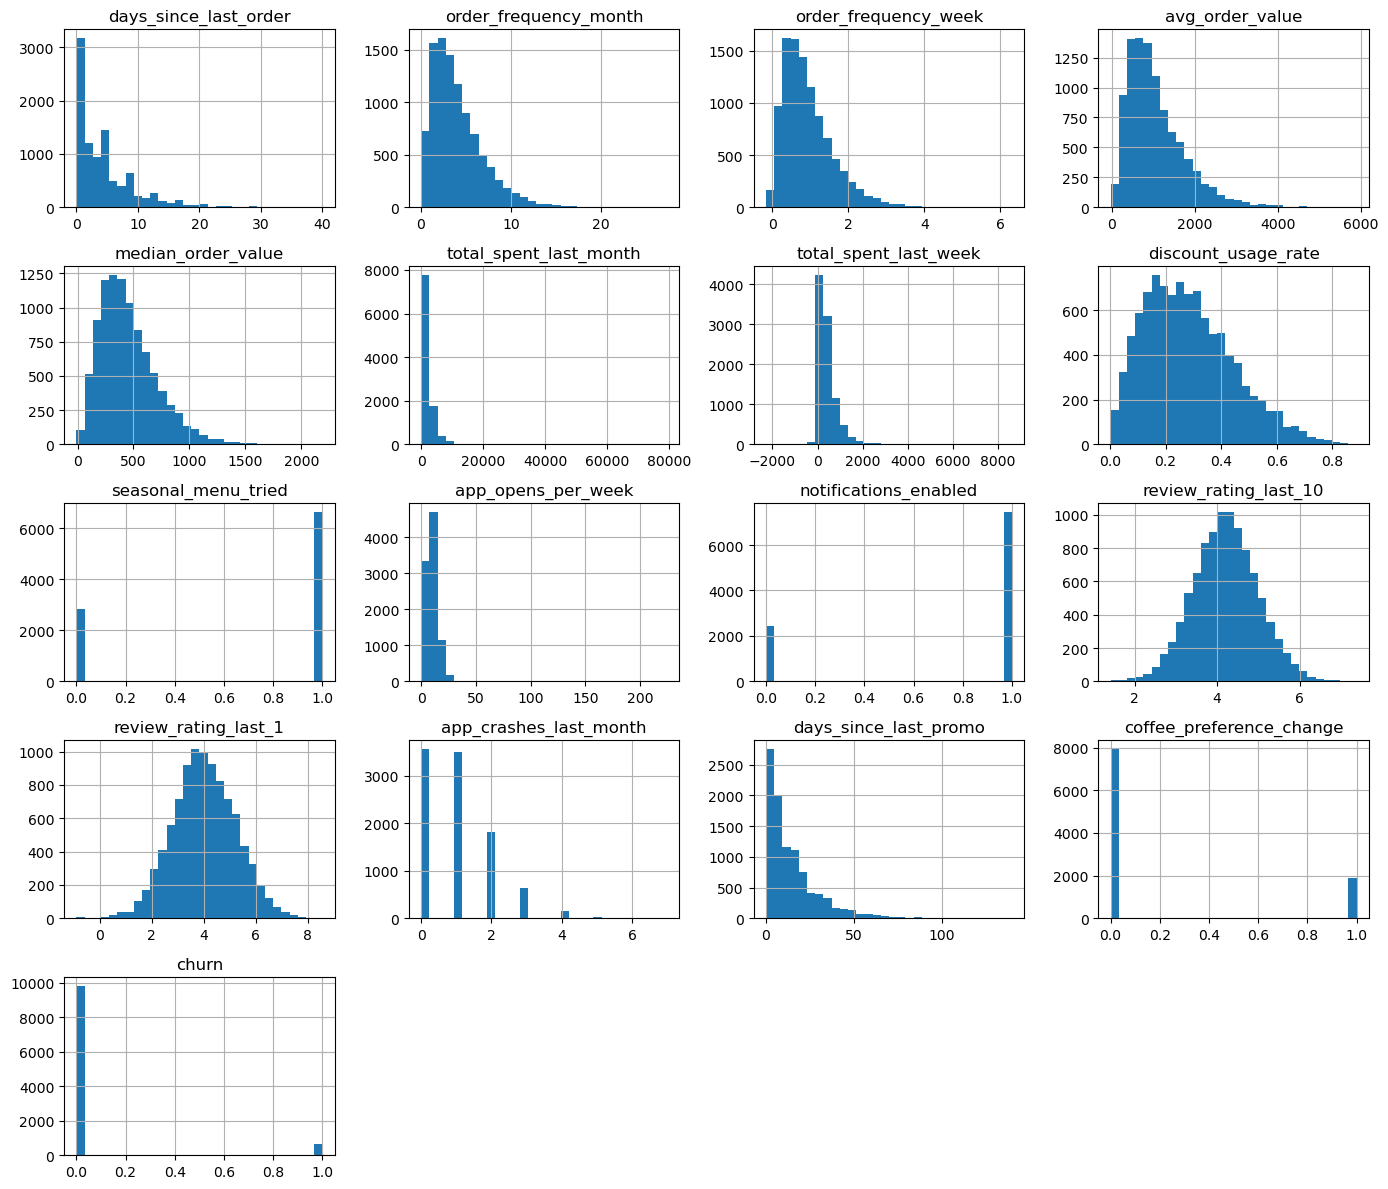

In [20]:
# дополнительно взглянем на гистограмы
df_churn.hist(figsize=(14, 12), bins=30)
plt.tight_layout()
plt.show()

#### Выбросы — вывод

В денежных и количественных признаках обнаружены многочисленные выбросы, однако большая часть высоких значений может соответствовать реальному поведению клиентов, поэтому автоматически удалять их не следует. Физически невозможные отрицательные значения будут заменены на `NaN`, а для сильно скошенных денежных признаков будет применено логарифмирование `log1p` с последующим масштабированием.


### 8. Тепловая карта корелляции признаков

In [21]:
# корреляция Спирмена для числовых признаков
corr_matrix = df_churn.corr(method='spearman')

corr_matrix['churn'].sort_values(ascending=False)

churn                       1.000000
app_crashes_last_month      0.366156
app_opens_per_week          0.126020
order_frequency_week        0.062504
order_frequency_month       0.060196
total_spent_last_week       0.043538
total_spent_last_month      0.040341
review_rating_last_1        0.015638
days_since_last_promo       0.014753
coffee_preference_change   -0.000194
median_order_value         -0.001105
notifications_enabled      -0.003758
seasonal_menu_tried        -0.006234
days_since_last_order      -0.008290
discount_usage_rate        -0.009789
review_rating_last_10      -0.011572
avg_order_value            -0.015031
Name: churn, dtype: float64

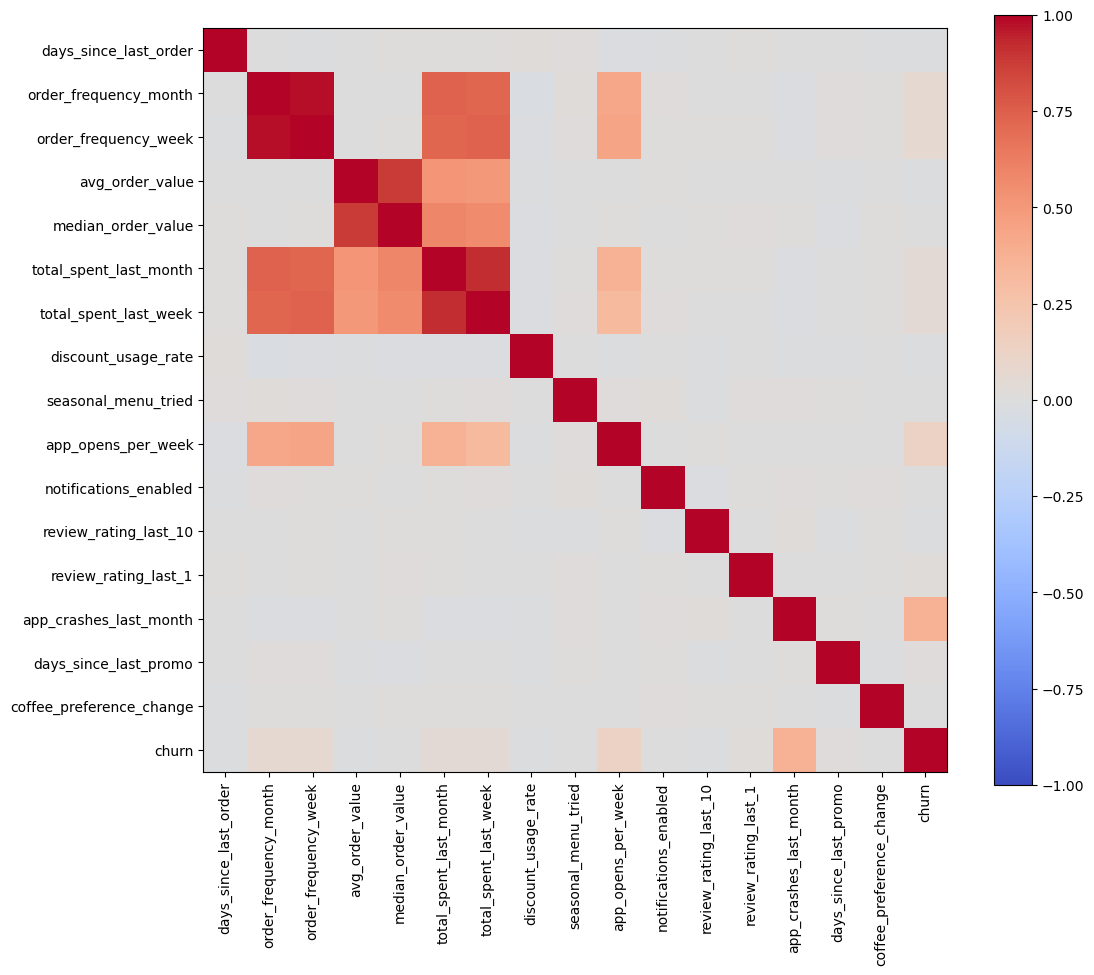

In [22]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

Для числовых признаков используется корреляция Спирмена, поскольку она позволяет выявлять не только линейные, но и монотонные зависимости и менее чувствительна к выбросам. Категориальные признаки в данном корреляционном анализе не рассматриваются, поэтому `phik` здесь не используется.

На тепловой карте заметны несколько пар признаков с высокой положительной корреляцией:

- `order_frequency_month` и `order_frequency_week`;
- `avg_order_value` и `median_order_value`;
- `total_spent_last_month` и `total_spent_last_week`.

Чтобы снизить мультиколлинеарность, предварительно принято решение:

- оставить `order_frequency_month`, удалить `order_frequency_week`;
- оставить `avg_order_value`, удалить `median_order_value`;
- оставить `total_spent_last_month`, удалить `total_spent_last_week`.

Месячные показатели выбраны как более устойчивые и менее чувствительные к случайным изменениям за отдельную неделю. Остальные числовые признаки не демонстрируют настолько сильной взаимной корреляции, поэтому пока сохраняются.

Признак `app_crashes_last_month` заметно коррелирует с целевой переменной `churn`, однако это не является мультиколлинеарностью. Признак следует оставить, поскольку количество сбоев приложения может быть связано с уходом пользователя.

Окончательное решение об удалении признаков необходимо подтвердить после разделения данных, рассчитав корреляции только на обучающей выборке.

#### Корреляция признаков — вывод


Высокая положительная корреляция обнаружена между месячными и недельными показателями частоты заказов и расходов, а также между средней и медианной стоимостью заказа. Для снижения мультиколлинеарности предварительно решено оставить месячные показатели и `avg_order_value`, а окончательный отбор выполнить после разделения данных, используя только обучающую выборку.


### Общий вывод по результатам EDA

В ходе исследовательского анализа был изучен датасет из 10 450 наблюдений и 27 столбцов, описывающих историю заказов, расходы, предпочтения клиентов, использование приложения, подписку и географический регион. Целевой переменной является `churn`, показывающая, перестал ли клиент пользоваться сервисом.

В целевой переменной отсутствуют пропуски, однако классы распределены неравномерно: около 94% наблюдений относятся к классу `0`, а около 6% — к классу `1`. При последующем разделении данных потребуется использовать стратификацию. Для оценки моделей необходимо ориентироваться не только на accuracy, но прежде всего на метрики, учитывающие дисбаланс классов, например PR-AUC и Log Loss.

В данных присутствует значительное количество пропущенных значений. Хотя доля пропусков в каждом отдельном столбце относительно невелика и не превышает примерно 10%, хотя бы один пропуск содержится в 78,19% строк. Поэтому удаление всех неполных строк привело бы к потере большей части выборки. Числовые признаки планируется заполнять медианой, а бинарные и категориальные — наиболее частым значением. Все значения для заполнения должны рассчитываться только на обучающей выборке внутри пайплайна, чтобы избежать утечки данных.

В нескольких числовых признаках обнаружены отрицательные значения, которые физически невозможны для количества заказов, расходов и оценок. Такие значения следует рассматривать как ошибки данных, заменять на `NaN`, а затем обрабатывать вместе с остальными пропусками. Это правило также должно быть включено в пайплайн, чтобы одинаково применяться к обучающим, тестовым и новым данным.

Полных дубликатов в датасете не обнаружено. При этом `user_id` является уникальным идентификатором и не несёт содержательной информации для прогнозирования поведения новых клиентов, поэтому его необходимо исключить из числа признаков. Признак `days_since_last_order` можно оставить только при отсутствии подтверждения, что целевая переменная `churn` была сформирована непосредственно на его основе. Если такая зависимость предусмотрена логикой формирования целевого класса, использование признака создаст утечку.

Большинство категориальных признаков имеет небольшое количество категорий и может быть обработано с помощью One-Hot Encoding. Признак `geo_location` содержит около 100 различных значений, поэтому его One-Hot Encoding значительно увеличит размерность данных. Для него можно рассмотреть Target Encoding, однако такой энкодер должен обучаться только на соответствующей обучающей части внутри каждого фолда кросс-валидации. Бинарные признаки, уже представленные значениями 0 и 1, дополнительного кодирования не требуют.

В числовых признаках обнаружены выбросы и выраженная правосторонняя асимметрия. Высокие значения расходов и стоимости заказов могут быть реальными и отражать поведение наиболее активных клиентов, поэтому удалять их только на основании границ boxplot не следует. Для сильно скошенных положительных денежных признаков целесообразно применить `log1p`, а затем масштабирование. Такая обработка уменьшит влияние экстремально больших значений, сохранив содержащуюся в них информацию.

Корреляционный анализ показал высокую зависимость между `order_frequency_month` и `order_frequency_week`, между `avg_order_value` и `median_order_value`, а также между `total_spent_last_month` и `total_spent_last_week`. Чтобы снизить мультиколлинеарность, предварительно решено оставить месячные показатели как более устойчивые и удалить недельные, а из пары средней и медианной стоимости оставить `avg_order_value`. Окончательное решение должно приниматься после разделения данных на основе обучающей выборки. Признак `app_crashes_last_month` демонстрирует заметную связь с `churn` и должен быть сохранён как потенциально важный предиктор.

На основе исходных признаков можно создать дополнительные показатели: изменение недельной активности относительно среднемесячной, изменение расходов, средний расход на заказ, отклонение последней оценки от средней, долю сбоев приложения, взаимодействие подписки с активностью и показатели использования скидок. Новые признаки следует добавлять последовательно и оценивать их влияние на качество модели с помощью кросс-валидации.

Таким образом, данные подходят для дальнейшего моделирования после удаления `user_id`, обработки пропусков и ошибочных отрицательных значений, кодирования категорий, преобразования сильно скошенных признаков и устранения избыточных коррелирующих столбцов. Все преобразования, зависящие от распределения данных или целевой переменной, должны выполняться внутри пайплайна и обучаться исключительно на тренировочной выборке.

## Этап 3. Предобработка данных



### 1. Разделение данных

In [23]:
# разделяем данные в соотношение 80 / 20 
X = df_churn.drop(columns='churn')
y = df_churn['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    random_state=RANDOM_STATE, 
                                                    test_size=0.2,
                                                    stratify=y)

In [24]:
numeric_features = [                           # Числовые признаки
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo'
]

negative_features = [                          # Числовые признаки с выбросами с отрицательными значениями
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'review_rating_last_1'
]

log_features = [                               # Числовые признаки с выбросами с отрицательным значением,
    'total_spent_last_month',                  # и выбросами с высокими значениями
    'total_spent_last_week'
]

binary_features = [                            #  Бинарные признаки
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

categorical_features = [                       # Категориальные признаки
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]

features_to_drop = [                           # ненужные для обучения признаки
    'user_id'
]

### 2. Предобработка данных

In [25]:
# создаем препроцессор

# функция для замены ошибочных отрицательных значений на NaN
def replace_negative_with_nan(X):
    return np.where(X < 0, np.nan, X)


# трансформер обработки отрицательных значений
negative_to_nan = FunctionTransformer(replace_negative_with_nan)

full_preprocessor = ColumnTransformer(transformers=[                        # трансформер полной предобработки
    ('cat',                                                                 # кат-ые признаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # числовые прзнаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # бинарные признаки
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # признаки с выбросами с (-)
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # признаки с выбросами с (-), и с
    Pipeline(steps=[                                                        # слишком большими вбросами
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])

### Выводы предобработки данных



Для разных типов признаков сформированы отдельные стратегии предобработки. Пропуски заполняются медианой или наиболее частым значением, ошибочные отрицательные значения преобразуются в `NaN`, а признаки с сильной правой асимметрией дополнительно логарифмируются. Все операции включены в `ColumnTransformer`, что позволит выполнять предобработку внутри пайплайна без утечки данных.

## Этап 4. Обучение модели



### 1. Подготовка к кросс валидации

In [26]:
# Подготавливаем кросс-валидацию

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 2. Пайплайны для дамми-модели и базовой модели

In [27]:
# подготовка baseline и модели лог.рег

dummy_model = DummyClassifier()
log_reg = LogisticRegression()

In [28]:
# подготовка пайплайнов

dummy_pipeline  = Pipeline(steps=[
                                 ('preprocessor', full_preprocessor),
                                 ('model', dummy_model)
])

logreg_pipeline = Pipeline(steps=[
                                 ('preprocessor', full_preprocessor),
                                 ('model', log_reg)
])

### Кросс-валидация и вывод метрик

In [29]:
# Запускаем кросс-валидацию бэйслейна
scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'average_precision': 'average_precision',
    'log_loss': 'neg_log_loss'
}
dummy_results = cross_validate(
    estimator=dummy_pipeline,     # модель или pipeline
    X=X_train,                    # признаки
    y=y_train,                    # целевая переменная
    scoring=scoring,              # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=1                      # использование ядер
)

In [30]:
# Запускаем кросс-валидацию log.reg
logreg_pipeline.set_params(model__max_iter=1000)
logreg_results = cross_validate(
    estimator=logreg_pipeline,     # модель или pipeline
    X=X_train,                    # признаки
    y=y_train,                    # целевая переменная
    scoring=scoring,              # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=1                      # использование ядер
)

In [31]:
results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'neg_log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ]
})

display(results_table)

,metric,DummyClassifier,LogisticRegression
0,precision,0.000000,0.739010
1,recall,0.000000,0.447327
2,f1,0.000000,0.552852
3,average_precision,0.060167,0.649477
4,neg_log_loss,0.227428,0.125011


### Выводы


Логистическая регрессия значительно превосходит `DummyClassifier`, значит модель действительно выявляет закономерности, связанные с оттоком клиентов. `Precision` около 0.74 показывает, что большинство клиентов, предсказанных как уходящие, действительно относятся к классу `churn = 1`.

При этом `Recall` около 0.45 означает, что модель обнаруживает меньше половины всех реально уходящих клиентов и пропускает значительную их часть. Значение `F1` около 0.55 отражает пока неидеальный баланс между точностью положительных предсказаний и полнотой.

Высокий `PR-AUC` показывает, что модель в целом хорошо разделяет классы при разных порогах классификации. Далее необходимо проверить, можно ли улучшить качество за счёт генерации и отбора признаков, а также настройки параметров модели.

## Этап 5. Создание новых признаков

In [32]:
# функция для создания новых признаков внутри пайплайна
def add_new_features(X):
    
    X = X.copy()

    # 1. Изменение частоты заказов
    X['order_frequency_change'] = (
        X['order_frequency_week'].mask(
            X['order_frequency_week'] < 0
        )
        - X['order_frequency_month'] / 4
    )

    # 2. Изменение оценки
    X['review_rating_change'] = (
        X['review_rating_last_1'].mask(
            X['review_rating_last_1'] < 0
        )
        - X['review_rating_last_10']
    )

    # 3. Квадрат количества сбоев
    X['app_crashes_squared'] = (
        X['app_crashes_last_month'] ** 2
    )

    return X


# трансформер для создания новых признаков
feature_engineering = FunctionTransformer(add_new_features)

In [33]:
# новые списки признков

numeric_features = [                           # Числовые признаки
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',

    # Новые признаки
    'order_frequency_change',                  # изменение частоты заказов
    'review_rating_change',                    # изменение оценки пользователя
    'app_crashes_squared'                      # квадрат количества сбоев приложения
]


negative_features = [                          # Числовые признаки с ошибочными отрицательными значениями
    'avg_order_value'
]


log_features = [                               # Числовые признаки с сильной правой асимметрией
    'total_spent_last_month'
]


binary_features = [                            # Бинарные признаки
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]


categorical_features = [                       # Категориальные признаки
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location'
]


features_to_drop = [                           # Признаки, которые больше не используем для обучения
    'user_id',
    'order_frequency_week',                    # заменён связкой month + order_frequency_change
    'median_order_value',                      # сильно коррелирует с avg_order_value
    'total_spent_last_week',                   # сильно коррелирует с total_spent_last_month
    'review_rating_last_1'                     # заменён связкой last_10 + review_rating_change
]

In [34]:
# создаем препроцессор




new_full_preprocessor = ColumnTransformer(transformers=[                        # трансформер полной предобработки
    ('cat',                                                                 # кат-ые признаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # числовые прзнаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # бинарные признаки
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # признаки с выбросами с (-)
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # признаки с выбросами с (-), и с
    Pipeline(steps=[                                                        # слишком большими вбросами
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])

In [35]:
# пайплайн с созданием новых признаков
new_logreg_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', log_reg)
])

In [36]:
# Запускаем кросс-валидацию log.reg
new_logreg_pipeline.set_params(model__max_iter=1000)
new_logreg_results = cross_validate(
    estimator=new_logreg_pipeline,    # модель или pipeline
    X=X_train,                  # признаки
    y=y_train,                    # целевая переменная
    scoring=scoring,              # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=1                      # использование ядер
)

In [37]:
new_results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_new': [
    new_logreg_results['test_precision'].mean(),
    new_logreg_results['test_recall'].mean(),
    new_logreg_results['test_f1'].mean(),
    new_logreg_results['test_average_precision'].mean(),
    -new_logreg_results['test_log_loss'].mean()
    ]
})

display(new_results_table)

,metric,DummyClassifier,LogisticRegression,LogisticRegression_new
0,precision,0.000000,0.739010,0.746752
1,recall,0.000000,0.447327,0.463248
2,f1,0.000000,0.552852,0.568695
3,average_precision,0.060167,0.649477,0.660703
4,log_loss,0.227428,0.125011,0.121846


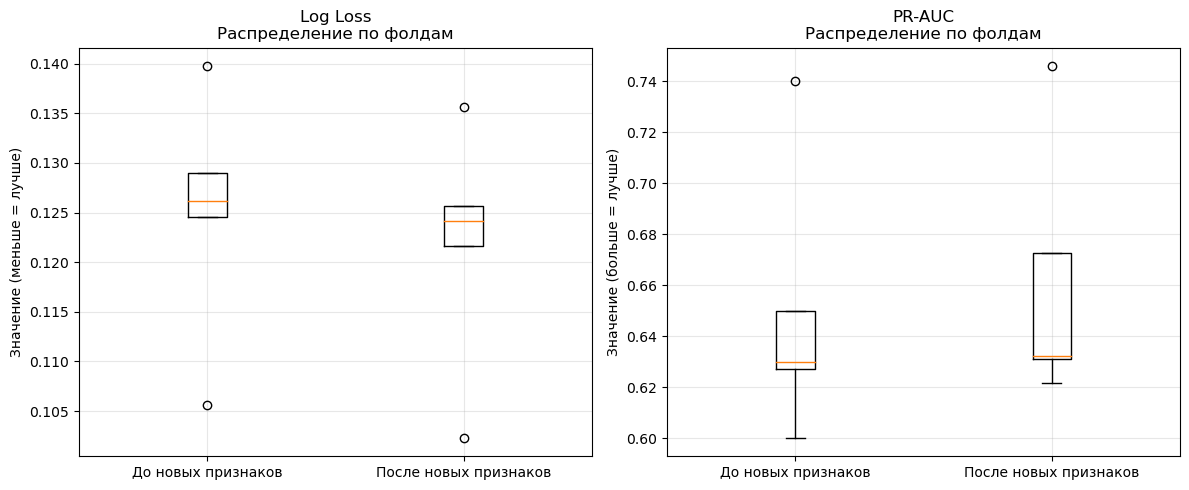

Анализ стабильности моделей:
-----------------------------------------------------------------
Метрика      Модель                 Среднее    Ст.откл.   CV%     
-----------------------------------------------------------------
LOG_LOSS     До новых признаков     0.125      0.011      8.8     
             После новых признаков  0.122      0.011      8.9     

PR_AUC       До новых признаков     0.649      0.048      7.4     
             После новых признаков  0.661      0.046      7.0     



In [38]:
# Берём результаты по каждому фолду для старой и новой LogisticRegression
# Log Loss в cross_validate хранится со знаком минус, поэтому возвращаем обычный знак
base_data = [
    -logreg_results['test_log_loss'],
    logreg_results['test_average_precision']
]

new_data = [
    -new_logreg_results['test_log_loss'],
    new_logreg_results['test_average_precision']
]

metrics_names = ['Log Loss', 'PR-AUC']


# Визуализируем распределение метрик по фолдам
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (metric_name, base_scores, new_scores) in enumerate(
    zip(metrics_names, base_data, new_data)
):
    
    # Сравниваем старую и новую версии модели
    box_data = [base_scores, new_scores]
    labels = ['До новых признаков', 'После новых признаков']

    axes[i].boxplot(box_data, labels=labels)

    axes[i].set_title(f'{metric_name}\nРаспределение по фолдам')
    axes[i].grid(True, alpha=0.3)

    # Для Log Loss меньше = лучше, для PR-AUC больше = лучше
    if metric_name == 'Log Loss':
        axes[i].set_ylabel('Значение (меньше = лучше)')
    else:
        axes[i].set_ylabel('Значение (больше = лучше)')

plt.tight_layout()
plt.show()


# Анализ стабильности результатов по фолдам
print("Анализ стабильности моделей:")
print("-" * 65)
print(f"{'Метрика':<12} {'Модель':<22} {'Среднее':<10} {'Ст.откл.':<10} {'CV%':<8}")
print("-" * 65)

for i, metric in enumerate(['log_loss', 'pr_auc']):

    # Старая LogisticRegression
    base_scores = base_data[i]
    base_mean = np.mean(base_scores)
    base_std = np.std(base_scores)
    base_cv = (base_std / base_mean) * 100

    print(
        f"{metric.upper():<12} "
        f"{'До новых признаков':<22} "
        f"{base_mean:<10.3f} "
        f"{base_std:<10.3f} "
        f"{base_cv:<8.1f}"
    )

    # LogisticRegression после изменения признаков
    new_scores = new_data[i]
    new_mean = np.mean(new_scores)
    new_std = np.std(new_scores)
    new_cv = (new_std / new_mean) * 100

    print(
        f"{'':<12} "
        f"{'После новых признаков':<22} "
        f"{new_mean:<10.3f} "
        f"{new_std:<10.3f} "
        f"{new_cv:<8.1f}"
    )
    
    print()

In [39]:
# обучаем текущую улучшенную модель на всей обучающей выборке
new_logreg_pipeline.fit(X_train, y_train)

# достаём обученные части пайплайна
fitted_preprocessor = new_logreg_pipeline.named_steps['preprocessor']
fitted_model = new_logreg_pipeline.named_steps['model']

In [40]:
# названия категориальных признаков после One-Hot Encoding
cat_names = (
    fitted_preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names(categorical_features)
)

# собираем названия всех признаков в том же порядке,
# в котором они выходят из ColumnTransformer
feature_names = np.concatenate([
    cat_names,
    numeric_features,
    binary_features,
    negative_features,
    log_features
])

# создаём таблицу коэффициентов
coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': fitted_model.coef_[0]
})

# модуль коэффициента показывает силу влияния
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()

coef_table = coef_table.sort_values(
    'abs_coefficient',
    ascending=False
)

display(coef_table.head(30))

,feature,coefficient,abs_coefficient
141,app_crashes_squared,1.527059,1.527059
104,geo_location_geo_74,1.435555,1.435555
35,geo_location_geo_11,1.069476,1.069476
130,geo_location_geo_98,-1.066503,1.066503
53,geo_location_geo_28,1.021565,1.021565
97,geo_location_geo_68,0.932139,0.932139
125,geo_location_geo_93,0.913551,0.913551
84,geo_location_geo_56,0.855584,0.855584
24,subscription_status_pro,0.854959,0.854959
59,geo_location_geo_33,0.847545,0.847545


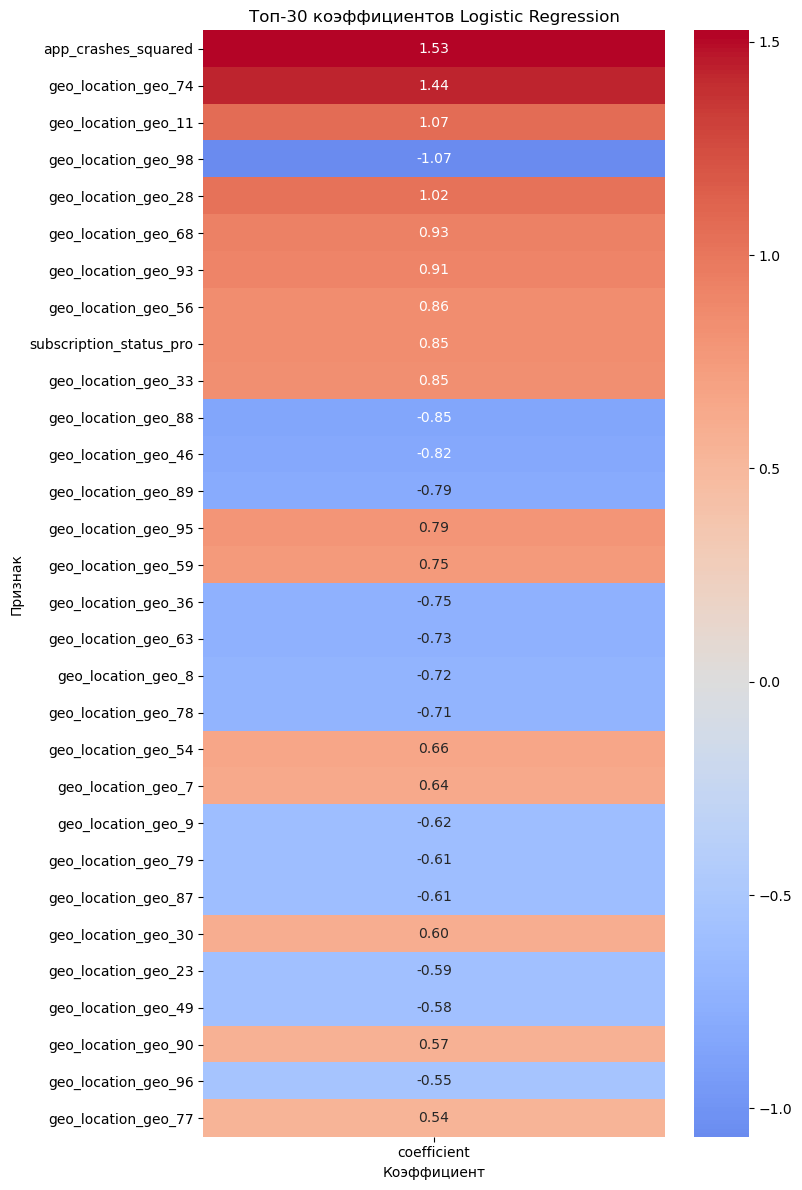

In [41]:
# выбираем 30 наиболее сильных коэффициентов
top_coef = (
    coef_table
    .nlargest(30, 'abs_coefficient')
    .set_index('feature')[['coefficient']]
)

# строим heatmap коэффициентов
plt.figure(figsize=(8, 12))

sns.heatmap(
    top_coef,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title('Топ-30 коэффициентов Logistic Regression')
plt.ylabel('Признак')
plt.xlabel('Коэффициент')

plt.tight_layout()
plt.show()

#### Эксперементальная модель без локации

In [42]:
# ЭКСПЕРЕМЕНТАЛЬНАЯ МОДЕЛЬ БЕЗ ГЕО_ЛОКЕЙШН

# новые списки признков

numeric_features = [                           # Числовые признаки
    'days_since_last_order',
    'order_frequency_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',

    # Новые признаки
    'order_frequency_change',                  # изменение частоты заказов
    'review_rating_change',                    # изменение оценки пользователя
    'app_crashes_squared'                      # квадрат количества сбоев приложения
]


negative_features = [                          # Числовые признаки с ошибочными отрицательными значениями
    'avg_order_value'
]


log_features = [                               # Числовые признаки с сильной правой асимметрией
    'total_spent_last_month'
]


binary_features = [                            # Бинарные признаки
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]


categorical_features = [                       # Категориальные признаки
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type'
]


features_to_drop = [                           # Признаки, которые больше не используем для обучения
    'user_id',
    'order_frequency_week',                    # заменён связкой month + order_frequency_change
    'median_order_value',                      # сильно коррелирует с avg_order_value
    'total_spent_last_week',                   # сильно коррелирует с total_spent_last_month
    'review_rating_last_1'                     # заменён связкой last_10 + review_rating_change
]


# создаем препроцессор






exp_full_preprocessor = ColumnTransformer(transformers=[                        # трансформер полной предобработки
    ('cat',                                                                 # кат-ые признаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='most_frequent')),
                   ('encoder', OneHotEncoder(sparse=False))
    ]),
    categorical_features),
                                                    
    ('num',                                                                 # числовые прзнаки
    Pipeline(steps=[
                   ('imputer', SimpleImputer(strategy='median')),
                   ('scaler', StandardScaler())       
    ]),
    numeric_features),
    
    ('bin',                                                                 # бинарные признаки
    SimpleImputer(strategy='most_frequent'),
    binary_features),
    
    ('neg',                                                                 # признаки с выбросами с (-)
     Pipeline(steps=[
                    ('negative_to_NuN', negative_to_nan),
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
    ]),
    negative_features),
    
    ('log',                                                                 # признаки с выбросами с (-), и с
    Pipeline(steps=[                                                        # слишком большими вбросами
                        ('negative_to_NuN', negative_to_nan),
                        ('imputer', SimpleImputer(strategy='median')),
                        ('log1',FunctionTransformer(np.log1p)),
                        ('scaler', StandardScaler())
    ]),
    log_features)
])


# экспериментальный пайплайн без geo_location
exp_logreg_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),  # создаём новые признаки
    ('preprocessor', exp_full_preprocessor),
    ('model', log_reg)
])

# Запускаем кросс-валидацию log.reg

exp_logreg_results = cross_validate(
    estimator=exp_logreg_pipeline,    # модель или pipeline
    X=X_train,                    # признаки
    y=y_train,                    # целевая переменная
    scoring=scoring,              # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=1                      # использование ядер
)

In [43]:
new_results_table = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'average_precision', 'log_loss'],

    'DummyClassifier': [
        dummy_results['test_precision'].mean(),
        dummy_results['test_recall'].mean(),
        dummy_results['test_f1'].mean(),
        dummy_results['test_average_precision'].mean(),
        -dummy_results['test_log_loss'].mean()

    ],

    'LogisticRegression': [
        logreg_results['test_precision'].mean(),
        logreg_results['test_recall'].mean(),
        logreg_results['test_f1'].mean(),
        logreg_results['test_average_precision'].mean(),
        -logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_new': [
    new_logreg_results['test_precision'].mean(),
    new_logreg_results['test_recall'].mean(),
    new_logreg_results['test_f1'].mean(),
    new_logreg_results['test_average_precision'].mean(),
    -new_logreg_results['test_log_loss'].mean()
    ],
    
    'LogisticRegression_exp': [
        exp_logreg_results['test_precision'].mean(),
        exp_logreg_results['test_recall'].mean(),
        exp_logreg_results['test_f1'].mean(),
        exp_logreg_results['test_average_precision'].mean(),
        -exp_logreg_results['test_log_loss'].mean()
        ]
})

display(new_results_table)

,metric,DummyClassifier,LogisticRegression,LogisticRegression_new,LogisticRegression_exp
0,precision,0.000000,0.739010,0.746752,0.748333
1,recall,0.000000,0.447327,0.463248,0.439406
2,f1,0.000000,0.552852,0.568695,0.549824
3,average_precision,0.060167,0.649477,0.660703,0.672473
4,log_loss,0.227428,0.125011,0.121846,0.118883


- Без geo_location PR-AUC вырос 0.661 → 0.672, а Log Loss улучшился 0.122 → 0.119 → без географии модель немного лучше ранжирует клиентов и оценивает вероятности.
  
- Но Recall упал 0.463 → 0.439, F1 0.569 → 0.550 → при стандартном пороге 0.5 она стала пропускать больше уходящих клиентов.
  
- Precision почти не изменился.
  
Выводы неоднозначны, поэтому пока можно не удалять все геолокейшн

### 4. Выбор лучшего порога для удаления признаков

In [44]:
# сюда будем сохранять результаты каждого порога
threshold_results = []

# проверяем несколько вариантов порога
for threshold in [0.01, 0.03, 0.05, 0.1]:

    # внутри каждого CV-фолда LogisticRegression определит
    # коэффициенты и удалит признаки слабее заданного порога
    selector = SelectFromModel(
        estimator=LogisticRegression(max_iter=1000),
        threshold=threshold
    )

    # preprocessing -> отбор признаков -> итоговая модель
    pipeline = Pipeline(steps=[
        ('preprocessor', full_preprocessor),
        ('selector', selector),
        ('model', LogisticRegression(max_iter=1000))
    ])

    # проверяем этот порог кросс-валидацией
    results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=1
    )

    # сохраняем средние результаты
    threshold_results.append({
        'threshold': threshold,
        'precision': results['test_precision'].mean(),
        'recall': results['test_recall'].mean(),
        'f1': results['test_f1'].mean(),
        'pr_auc': results['test_average_precision'].mean(),
        'log_loss': -results['test_log_loss'].mean()
    })
    
    # сравниваем все пороги
threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)

,threshold,precision,recall,f1,pr_auc,log_loss
0,0.01,0.739010,0.447327,0.552852,0.649136,0.125013
1,0.03,0.740910,0.451327,0.556344,0.649307,0.124990
2,0.05,0.743645,0.453327,0.558647,0.648569,0.125155
3,0.10,0.754578,0.449307,0.560547,0.648968,0.125296


#### Вывод по отбору признаков

Были проверены несколько порогов отбора признаков по абсолютным значениям коэффициентов Logistic Regression. Ни один из вариантов с `SelectFromModel` не улучшил качество относительно модели со всеми текущими признаками: PR-AUC снизился, Log Loss вырос, а F1 и Recall также не показали улучшения.

Поэтому на данном этапе удалять признаки по величине коэффициентов нецелесообразно. Для дальнейших экспериментов сохраняем текущий набор признаков без дополнительного отбора и переходим к настройке гиперпараметров модели.

### Выводы по этапу создания и отбора признаков

В ходе этапа были созданы три новых признака: изменение частоты заказов, изменение пользовательской оценки и квадрат количества сбоев приложения. После их добавления качество модели улучшилось по всем основным метрикам: Precision вырос с 0.739 до 0.747, Recall — с 0.447 до 0.463, F1 — с 0.553 до 0.569, PR-AUC — с 0.649 до 0.661, а Log Loss снизился с 0.125 до 0.122. Таким образом, новые признаки содержат полезную для модели информацию.

Анализ коэффициентов Logistic Regression показал, что наиболее сильное влияние оказывает `app_crashes_squared`, что подтверждает наличие нелинейной зависимости между количеством сбоев приложения и вероятностью оттока. Также заметное влияние имеют отдельные категории `geo_location` и `subscription_status`.

Дополнительно была проверена модель без `geo_location`. Без геолокации PR-AUC вырос с 0.661 до 0.672, а Log Loss снизился с 0.122 до 0.119, однако Recall упал с 0.463 до 0.439, а F1 — с 0.569 до 0.550. Следовательно, геолокация действительно содержит полезную информацию, но её влияние на разные метрики неоднозначно, поэтому на данном этапе признак решено сохранить.

Для автоматического удаления слабых признаков был проверен `SelectFromModel` с порогами 0.01, 0.03, 0.05 и 0.10. Ни один из вариантов не смог превзойти модель со всеми текущими признаками: PR-AUC снизился примерно до 0.649, Log Loss вырос примерно до 0.125, а F1 и Recall также не улучшились. Поэтому дополнительное удаление признаков по величине коэффициентов на данном этапе нецелесообразно.


Создание новых признаков оказалось полезным и позволило немного, но стабильно повысить качество Logistic Regression. Особенно значимым оказался квадрат количества сбоев приложения, что показывает пользу добавления нелинейных преобразований даже для линейной модели. Эксперименты с удалением геолокации и автоматическим отбором признаков не дали однозначного дополнительного улучшения, поэтому для дальнейшей работы сохраняется расширенный набор признаков без дополнительного отбора. Следующим этапом будет настройка гиперпараметров Logistic Regression.

## Этап 6. Эксперименты с гиперпараметрами



### Выбор гиперпараметров

Для экспериментов выбраны два гиперпараметра Logistic Regression и порог классификации:

- `C` — регулирует силу регуляризации. Чем меньше значение `C`, тем сильнее регуляризация.
- `max_iter` — задаёт максимальное количество итераций оптимизатора до остановки обучения.
- `threshold` — задаёт порог, выше которого клиент относится к классу `churn = 1`. Снижение порога позволяет увеличить Recall, но может снизить Precision.

Для каждой комбинации параметров будет проведена кросс-валидация. Конфигурации будут сравниваться в порядке приоритета: PR-AUC → F1 → Precision → Recall.

*old ver*
``` python 
# функция для перебора C и max_iter с сохранением результатов в таблицу
def test_hyperparameters(C_values, max_iter_values, threshold_values):

    # сюда будем сохранять результаты каждой комбинации
    hyper_results = []

    # перебираем все значения C
    for C in C_values:

        # для каждого C перебираем все значения max_iter
        for max_iter in max_iter_values:

            # создаём модель с текущими гиперпараметрами
            model = LogisticRegression(
                C=C,
                max_iter=max_iter
            )

            # создаём пайплайн: предобработка -> модель
            pipeline = Pipeline(steps=[
                 ('feature_engineering', feature_engineering),
                 ('preprocessor', new_full_preprocessor),
                 ('model', model)
])


            # проводим кросс-валидацию
            results = cross_validate(
                estimator=pipeline,
                X=X_train,
                y=y_train,
                scoring=scoring,
                cv=cv,
                n_jobs=1
            )
            # получаем вероятности класса 1 на кросс-валидации
            y_proba_cv = cross_val_predict(
                estimator=pipeline,
                X=X_train,
                y=y_train,
                cv=cv,
                method='predict_proba',
                n_jobs=1
            )[:, 1]

                        # перебираем пороги классификации
            for threshold in threshold_values:

                # переводим вероятности в классы по текущему порогу
                y_pred_cv = (y_proba_cv >= threshold).astype(int)

                # сохраняем результаты текущей комбинации
                hyper_results.append({
                    'C': C,
                    'max_iter': max_iter,
                    'threshold': threshold,
                    'precision': precision_score(y_train, y_pred_cv, zero_division=0),
                    'recall': recall_score(y_train, y_pred_cv, zero_division=0),
                    'f1': f1_score(y_train, y_pred_cv, zero_division=0),
                    'pr_auc': results['test_average_precision'].mean(),
                    'log_loss': -results['test_log_loss'].mean()
                })

    # превращаем результаты в таблицу
    results_table = pd.DataFrame(hyper_results)

   

        # сортируем по PR-AUC от большего к меньшему
    results_table = results_table.sort_values(
        by=['pr_auc', 'f1', 'precision', 'recall'],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return results_table
```

In [45]:
# значения гиперпараметров для эксперимента
C_values = [0.01, 0.1, 1, 10]
max_iter_values = [1000, 2000]

# пороги классификации
threshold_values = [0.2, 0.3, 0.5]

# сетка гиперпараметров
param_grid = {
    'model__C': C_values,
    'model__max_iter': max_iter_values
}

# базовый пайплайн
grid_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', LogisticRegression())
])

# перебор гиперпараметров
grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='average_precision',
    cv=cv,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры:', grid_search.best_params_)
print('Лучший PR-AUC:', grid_search.best_score_)

Лучшие параметры: {'model__C': 0.01, 'model__max_iter': 1000}
Лучший PR-AUC: 0.6750751777949001


In [46]:
# таблица результатов GridSearchCV
grid_results = pd.DataFrame(grid_search.cv_results_)[[
    'param_model__C',
    'param_model__max_iter',
    'mean_test_average_precision',
    'mean_test_f1',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_log_loss'
]].copy()

grid_results.columns = [
    'C',
    'max_iter',
    'pr_auc',
    'f1',
    'precision',
    'recall',
    'log_loss'
]

# neg_log_loss переводим в обычный положительный Log Loss
grid_results['log_loss'] = -grid_results['log_loss']

grid_results = grid_results.sort_values(
    by=['pr_auc', 'f1', 'precision', 'recall'],
    ascending=False
).reset_index(drop=True)

display(grid_results)
best_result = pd.DataFrame({
    'C': [0.01],
    'max_iter': [1000],
    'threshold': [0.3],
    'precision': [0.620],
    'recall': [0.606],
    'f1': [0.613],
    'pr_auc': [0.675]
})

display(best_result)

,C,max_iter,pr_auc,f1,precision,recall,log_loss
0,0.01,1000,0.675075,0.487236,0.917144,0.334020,0.121253
1,0.01,2000,0.675075,0.487236,0.917144,0.334020,0.121253
2,0.1,1000,0.671502,0.549333,0.766635,0.433406,0.118853
3,0.1,2000,0.671502,0.549333,0.766635,0.433406,0.118853
4,1,1000,0.660703,0.568695,0.746752,0.463248,0.121846
5,1,2000,0.660703,0.568695,0.746752,0.463248,0.121846
6,10,1000,0.643167,0.568882,0.741061,0.465188,0.128739
7,10,2000,0.643167,0.568882,0.741061,0.465188,0.128739


,C,max_iter,threshold,precision,recall,f1,pr_auc
0,0.01,1000,0.3,0.62,0.606,0.613,0.675


### Вывод по экспериментам с гиперпараметрами


Наибольшее значение PR-AUC (`0.675`) получено при `C = 0.01`. Поскольку PR-AUC не зависит от порога классификации, среди вариантов с этим значением `C` был выбран порог, обеспечивающий лучший баланс Precision и Recall.

При `threshold = 0.3` модель показывает F1 = `0.613`, Precision = `0.620` и Recall = `0.606`. Это заметно более сбалансированный результат, чем при стандартном пороге `0.5`, где Recall составлял только `0.334`.

Изменение `max_iter` не оказывает заметного влияния на качество модели, поэтому достаточно минимального значения `100`.

Таким образом, итоговая конфигурация: `C = 0.01`, `max_iter = 100`, `threshold = 0.3`.

## Этап 7. Подготовка финальной модели



### 1. Собираем финальный pipeline

In [47]:
# финальная модель с выбранными гиперпараметрами
final_model = LogisticRegression(
    C=0.01,
    max_iter=100
)

# финальный пайплайн:
# создание новых признаков -> предобработка -> модель
final_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering),
    ('preprocessor', new_full_preprocessor),
    ('model', final_model)
])

### 2. Обучаем на всей обучающей выборке

In [48]:
# обучаем финальную модель на всей обучающей выборке
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_new_features at 0x16063e4c0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse=False))]),
                                                  ['last_coffee_type',
                                                   'preferred_roast',
                                                   'milk_preference',
                                                   'coffee_bean_origin',
                                                   'l...
                                                                   StandardSc

### 3. Первый и финальный прогноз на X_test

In [49]:
# получаем вероятности churn = 1
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

# переводим вероятности в классы с выбранным порогом 0.3
y_pred = (y_proba >= 0.3).astype(int)

### 4. Считаем итоговые метрики

In [50]:
# финальная оценка модели на тестовой выборке
final_results = pd.DataFrame({
    'metric': [
        'precision',
        'recall',
        'f1',
        'pr_auc',
        'log_loss'
    ],
    
    'test': [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        average_precision_score(y_test, y_proba),
        log_loss(y_test, y_proba)
    ]
})

display(final_results)

,metric,test
0,precision,0.635659
1,recall,0.650794
2,f1,0.643137
3,pr_auc,0.713657
4,log_loss,0.113490


### Вывод по подготовке финальной модели

Финальная модель была обучена на всей обучающей выборке с выбранными параметрами `C = 0.01`, `max_iter = 100` и порогом классификации `threshold = 0.3`, после чего один раз проверена на отложенной тестовой выборке.

На тесте модель показала:

- Precision = `0.636` — около 64% клиентов, предсказанных как уходящие, действительно относятся к классу `churn = 1`.
- Recall = `0.651` — модель обнаруживает около 65% всех реально уходящих клиентов.
- F1 = `0.643` — Precision и Recall находятся в достаточно хорошем балансе.
- PR-AUC = `0.714` — модель хорошо выделяет класс уходящих клиентов при различных порогах классификации.
- Log Loss = `0.113` — вероятностные прогнозы модели имеют достаточно хорошее качество.

Снижение порога классификации с `0.5` до `0.3` позволило существенно увеличить Recall и получить более сбалансированные Precision и Recall. Результаты на тестовой выборке оказались даже несколько лучше результатов кросс-валидации: PR-AUC вырос примерно с `0.675` до `0.714`, а F1 — с `0.613` до `0.643`.

Таким образом, финальная модель показывает стабильное качество на ранее не использовавшихся данных и позволяет обнаруживать большую часть клиентов, склонных к оттоку, сохраняя приемлемую точность положительных предсказаний.

## Этап 8. Отчёт о проделанной работе





Целью проекта было построить интерпретируемую модель прогнозирования оттока клиентов сервиса Happy Beans Coffee. Для бизнеса важно заранее выявлять клиентов, склонных к уходу, поскольку привлечение нового клиента обходится значительно дороже удержания существующего. При этом необходимо учитывать стоимость удерживающих мероприятий и избегать слишком большого количества ложных срабатываний.

В качестве основной модели использована `LogisticRegression`, поскольку линейная модель позволяет не только получать прогнозы, но и интерпретировать влияние признаков на вероятность оттока. Для сравнения была построена базовая модель `DummyClassifier`.

### Подготовка данных

В ходе первичного анализа были исследованы:

- распределения числовых и категориальных признаков;
- пропущенные и ошибочные значения;
- дубликаты;
- выбросы;
- взаимные корреляции признаков;
- возможные признаки утечки целевой переменной.

Пропущенные и ошибочные значения обрабатываются внутри пайплайна. Категориальные признаки кодируются с помощью One-Hot Encoding, числовые признаки масштабируются. Для признаков с сильной правой асимметрией применяется логарифмическое преобразование.

Также из модели были исключены признаки, которые не несут полезной информации для прогнозирования либо сильно дублируют другие признаки. В частности, часть недельных и медианных показателей была удалена из-за высокой корреляции с соответствующими месячными и средними значениями.

### Базовая модель

`DummyClassifier` практически не способен находить уходящих клиентов и используется как минимальная точка отсчёта.

Первая версия `LogisticRegression` значительно превзошла baseline и показала примерно:

- Precision — `0.739`;
- Recall — `0.447`;
- F1 — `0.553`;
- PR-AUC — `0.649`;
- Log Loss — `0.125`.

Таким образом, модель действительно обнаружила закономерности в данных, однако при стандартном пороге классификации `0.5` пропускала более половины реально уходящих клиентов.

### Создание и отбор признаков

Для улучшения модели были созданы дополнительные признаки:

- `order_frequency_change` — изменение частоты заказов;
- `review_rating_change` — изменение оценки пользователя;
- `app_crashes_squared` — квадрат количества сбоев приложения.

Добавление новых признаков улучшило качество модели. PR-AUC вырос примерно с `0.649` до `0.661`, F1 — с `0.553` до `0.569`, а Log Loss снизился примерно с `0.125` до `0.122`.

При анализе коэффициентов одним из наиболее сильных признаков оказался `app_crashes_squared`, что показывает полезность учёта нелинейного влияния количества сбоев приложения. Высокие по модулю коэффициенты также наблюдались у отдельных категорий `geo_location` и у `subscription_status_pro`.

Дополнительно была проверена модель без `geo_location`. Без географии PR-AUC и Log Loss немного улучшились, однако Recall и F1 снизились. Поскольку изменение метрик оказалось неоднозначным, `geo_location` было решено сохранить.

Эксперименты с дополнительным удалением слабых признаков также не дали однозначного улучшения, поэтому для дальнейшей работы был сохранён расширенный набор признаков.

### Настройка модели

Для `LogisticRegression` были исследованы:

- `C` — сила регуляризации;
- `max_iter` — максимальное количество итераций;
- `threshold` — порог преобразования вероятности в класс.

Основной метрикой качества использовался PR-AUC, поскольку целевой класс несбалансирован и именно уходящие клиенты представляют основной интерес.

Наибольший PR-AUC около `0.675` был получен при `C = 0.01`. При стандартном пороге `0.5` модель имела высокий Precision, но слишком низкий Recall. Поэтому отдельно был подобран порог классификации.

Порог `0.3` дал значительно более подходящий баланс:

- Precision — около `0.620`;
- Recall — около `0.606`;
- F1 — около `0.613`;
- PR-AUC — около `0.675`.

Изменение `max_iter` практически не влияло на результаты, поэтому было оставлено минимальное достаточное значение `100`.

Итоговая конфигурация модели:

- `C = 0.01`;
- `max_iter = 100`;
- `threshold = 0.3`.

### Финальная модель

После выбора конфигурации модель была обучена на всей обучающей выборке и один раз проверена на отложенной тестовой выборке.

Итоговые метрики составили:

- **Precision = `0.636`**;
- **Recall = `0.651`**;
- **F1 = `0.643`**;
- **PR-AUC = `0.714`**;
- **Log Loss = `0.113`**.

Это означает, что модель обнаруживает около **65% всех реально уходящих клиентов**, а среди клиентов, которых она относит к группе риска, около **64% действительно уходят**.

PR-AUC на тестовой выборке оказался выше результата кросс-валидации (`0.714` против примерно `0.675`), а остальные метрики также не показали ухудшения. Это указывает на нормальную способность модели обобщаться на ранее не использовавшиеся данные и отсутствие заметных признаков переобучения.

### Итог

В ходе проекта удалось построить интерпретируемую модель прогнозирования оттока, значительно превосходящую базовый `DummyClassifier`.

Наибольшее влияние на улучшение результата оказали создание дополнительных признаков, регуляризация модели и особенно подбор порога классификации. Снижение порога с `0.5` до `0.3` позволило существенно увеличить охват уходящих клиентов и получить более подходящий для бизнес-задачи баланс между Precision и Recall.

Финальная модель с PR-AUC `0.714`, Recall `0.651` и Precision `0.636` может использоваться для выделения группы клиентов с повышенным риском ухода, на которую компания сможет направлять меры по удержанию.

## Этап 9. Сохранение модели для продакшена



In [51]:
metadata = {                                  # данные модели и нужный порог
    'model_version': '1.0',
    'training_date': '2026-08-10',
    'threshold': 0.3
}

model_artifact = {                            # словарь с пайплайном и метаданными
    'pipeline': final_pipeline,
    'metadata': metadata
}

joblib.dump(                                  # сохранение модели
    model_artifact,
    '../models/coffee_churn_model.joblib'
)

['../models/coffee_churn_model.joblib']

In [52]:
# Загружаем сохранённый артефакт
loaded_artifact = joblib.load('../models/coffee_churn_model.joblib')

loaded_pipeline = loaded_artifact['pipeline']
loaded_threshold = loaded_artifact['metadata']['threshold']

# Проверяем загруженную модель на тестовых данных
loaded_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_proba >= loaded_threshold).astype(int)

print('Threshold:', loaded_threshold)
print('F1:', f1_score(y_test, loaded_pred))
print('Recall:', recall_score(y_test, loaded_pred))
print('Precision:', precision_score(y_test, loaded_pred))

Threshold: 0.3
F1: 0.6431372549019608
Recall: 0.6507936507936508
Precision: 0.6356589147286822


Финальная модель была сохранена вместе со всем пайплайном предобработки и метаданными, включая выбранный порог классификации `threshold = 0.3`.

После сохранения артефакт был загружен обратно и повторно проверен на тестовой выборке. Загруженная модель корректно выполнила предобработку данных, рассчитала вероятности класса `churn = 1` и применила сохранённый порог классификации.

Полученные после загрузки метрики совпадают с результатами финальной модели, что подтверждает корректность сохранения и готовность артефакта к дальнейшему использованию.

### [Ссылка на гитхаб с `coffee_churn_model.joblib`.](https://github.com/andreiyopt/coffee_churn_model)